In [1]:
# ==============================================================================
# CELL 1: IMPORTS & SETUP
# ==============================================================================

import os
import time
import json
import warnings
import glob
import random
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, Normal
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GINConv, global_max_pool, global_mean_pool
import matplotlib.pyplot as plt
from matplotlib import gridspec
from IPython.display import clear_output

# Numba for fast penalty computation
from numba import njit, prange

# Hide warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# DEVICE DETECTION
# ==============================================================================

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print(f"✅ MPS (Metal) device detected: {torch.device('mps')}")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"✅ CUDA device detected")
else:
    DEVICE = torch.device("cpu")
    print(f"⚠️  No GPU detected, using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device set to: {DEVICE}")

/Users/neerajprao/Desktop/isro/layout_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ MPS (Metal) device detected: mps
PyTorch version: 2.13.0
Device set to: mps


In [2]:
# ==============================================================================
# CELL 2: CONFIG & HYPERPARAMETERS
# ==============================================================================

@dataclass
class Config:
    """
    All tunable hyperparameters in one place.
    Adjust any value here — no need to hunt through cells.
    """
    
    # ── Board Settings ──────────────────────────────────────────────────────────
    PANEL_WIDTH: float = 960.0          # mm
    PANEL_HEIGHT: float = 582.4         # mm
    BORDER_SPACING: float = 20.0        # mm
    CLEARANCE: float = 20.0             # mm default clearance
    CG_TOLERANCE: float = 1.0           # mm
    
    # ── Dataset ─────────────────────────────────────────────────────────────────
    DATASET_DIR: str = "./datasets"     # where .npz files live
    DATASET_SPLIT: float = 0.8          # 80% train / 20% val
    JITTER_STD: float = 15.0            # mm, noise added to dataset samples
    
    # ── Episode Settings ────────────────────────────────────────────────────────
    MAX_STEPS_PER_EPISODE: int = 50
    PENALTY_THRESHOLD: float = 1e-3     # terminate episode if below this
    TARGET_LAYOUT_COUNT: int = 5        # find 5 feasible layouts
    
    # ── Action Space ────────────────────────────────────────────────────────────
    DELTA_MAX_START: float = 30.0       # mm, initial max shift
    DELTA_MAX_END: float = 5.0          # mm, final max shift
    DELTA_ANNEAL_EPISODES: int = 500    # episodes to anneal delta_max
    
    # ── Reward Shaping ──────────────────────────────────────────────────────────
    CG_BONUS: float = 10.0              # reward when CG offset < tolerance
    STEP_PENALTY: float = 0.01          # per-step living penalty
    MOVE_PENALTY_COEF: float = 0.001    # coefficient for (dx² + dy²) penalty
    
    # ── GNN Architecture ────────────────────────────────────────────────────────
    NODE_FEATURE_DIM: int = 20          # static + dynamic node features
    EDGE_FEATURE_DIM: int = 5           # edge attributes
    GLOBAL_FEATURE_DIM: int = 5         # board-level features
    HIDDEN_DIM: int = 256               # GNN hidden size
    GNN_LAYERS: int = 3                 # number of GIN layers
    
    # ── PPO Training ────────────────────────────────────────────────────────────
    NUM_ENVS: int = 16                  # parallel environments (CPU)
    ROLLOUT_STEPS: int = 2048           # total steps per rollout (across all envs)
    MINIBATCH_SIZE: int = 64
    PPO_EPOCHS: int = 10                # gradient updates per rollout
    GAMMA: float = 0.99                 # discount factor
    GAE_LAMBDA: float = 0.95            # GAE lambda
    CLIP_EPS: float = 0.2               # PPO clipping epsilon
    VALUE_COEF: float = 0.5             # value loss coefficient
    ENTROPY_COEF: float = 0.01          # entropy bonus coefficient
    MAX_GRAD_NORM: float = 0.5          # gradient clipping
    LR: float = 3e-4                    # learning rate
    LR_WARMUP_STEPS: int = 1000         # linear warmup steps
    
    # ── Pretraining ─────────────────────────────────────────────────────────────
    PRETRAIN_EPOCHS: int = 50
    PRETRAIN_BATCH_SIZE: int = 32
    PRETRAIN_LR: float = 1e-3
    
    # ── Logging & Saving ────────────────────────────────────────────────────────
    LOG_INTERVAL: int = 10              # episodes between prints
    PLOT_INTERVAL: int = 50             # episodes between live plots
    SAVE_INTERVAL: int = 200            # episodes between checkpoints
    OUTPUT_DIR: str = "./checkpoints"
    
    # ── Penalty Weights (must match compute_fitness_core) ───────────────────────
    PENALTY_WEIGHT: float = 1e8


# Instantiate config
cfg = Config()

# Create output directory
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Print config summary
print("=" * 60)
print("CONFIGURATION SUMMARY")
print("=" * 60)
for key, value in vars(cfg).items():
    print(f"  {key:30s}: {value}")
print("=" * 60)

CONFIGURATION SUMMARY
  PANEL_WIDTH                   : 960.0
  PANEL_HEIGHT                  : 582.4
  BORDER_SPACING                : 20.0
  CLEARANCE                     : 20.0
  CG_TOLERANCE                  : 1.0
  DATASET_DIR                   : ./datasets
  DATASET_SPLIT                 : 0.8
  JITTER_STD                    : 15.0
  MAX_STEPS_PER_EPISODE         : 50
  PENALTY_THRESHOLD             : 0.001
  TARGET_LAYOUT_COUNT           : 5
  DELTA_MAX_START               : 30.0
  DELTA_MAX_END                 : 5.0
  DELTA_ANNEAL_EPISODES         : 500
  CG_BONUS                      : 10.0
  STEP_PENALTY                  : 0.01
  MOVE_PENALTY_COEF             : 0.001
  NODE_FEATURE_DIM              : 20
  EDGE_FEATURE_DIM              : 5
  GLOBAL_FEATURE_DIM            : 5
  HIDDEN_DIM                    : 256
  GNN_LAYERS                    : 3
  NUM_ENVS                      : 16
  ROLLOUT_STEPS                 : 2048
  MINIBATCH_SIZE                : 64
  PPO_EPOCHS      

In [3]:
# ==============================================================================
# CELL 3 (REVISED): DATA LOADING — newobj.json + .npz Inspection
# ==============================================================================

# ── 3.1: Load newobj.json (component specifications) ──────────────────────────

JSON_PATH = "newobj.json"

if not os.path.exists(JSON_PATH):
    raise FileNotFoundError(f"❌ {JSON_PATH} not found in working directory")

with open(JSON_PATH, 'r') as f:
    board_data = json.load(f)

print("=" * 60)
print("BOARD SPECIFICATION")
print("=" * 60)
for k, v in board_data['BOARD'].items():
    print(f"  {k:20s}: {v}")

print("\n" + "=" * 60)
print("FRONT COMPONENTS")
print("=" * 60)
for comp in board_data['COMPONENTS']['FRONT']:
    print(f"  {comp['Object name']:15s} | qty: {comp.get('Object qty', 1)} | shape: {comp['Shape']}")

print("\n" + "=" * 60)
print("BACK COMPONENTS")
print("=" * 60)
for comp in board_data['COMPONENTS']['BACK']:
    print(f"  {comp['Object name']:15s} | qty: {comp.get('Object qty', 1)} | shape: {comp['Shape']}")


# ── 3.2: Expand components with quantities ────────────────────────────────────

def expand_components(data: dict):
    """
    Expand components with Object qty > 1 into individual entries.
    Returns: list of component dicts with 'Is Back' flag
    """
    expanded = []
    
    for comp in data['COMPONENTS'].get('FRONT', []):
        qty = int(comp.get('Object qty', 1))
        for q in range(qty):
            c = comp.copy()
            c['Unique Name'] = f"{comp['Object name']}{q}" if qty > 1 else comp['Object name']
            c['Is Back'] = False
            expanded.append(c)
            
    for comp in data['COMPONENTS'].get('BACK', []):
        qty = int(comp.get('Object qty', 1))
        for q in range(qty):
            c = comp.copy()
            c['Unique Name'] = f"{comp['Object name']}{q}" if qty > 1 else comp['Object name']
            c['Is Back'] = True
            expanded.append(c)
            
    return expanded


components = expand_components(board_data)
NUM_COMPONENTS = len(components)

print(f"\n{'=' * 60}")
print(f"TOTAL EXPANDED COMPONENTS: {NUM_COMPONENTS}")
print(f"{'=' * 60}")
for i, c in enumerate(components):
    side = "BACK" if c['Is Back'] else "FRONT"
    shape = c['Shape']
    dims = f"{c.get('Length (mm)', c.get('Diameter (mm)'))}x{c.get('Breadth (mm)', c.get('Diameter (mm)'))}"
    print(f"  [{i:2d}] {c['Unique Name']:12s} | {side:5s} | {shape:9s} | {dims}")


# ── 3.3: Inspect .npz dataset files ───────────────────────────────────────────

npz_files = sorted(glob.glob(os.path.join(cfg.DATASET_DIR, "*.npz")))

print(f"\n{'=' * 60}")
print(f"DATASET INSPECTION")
print(f"{'=' * 60}")
print(f"  Dataset directory: {cfg.DATASET_DIR}")
print(f"  .npz files found:  {len(npz_files)}")

if len(npz_files) == 0:
    raise FileNotFoundError(
        f"❌ No .npz files found in '{cfg.DATASET_DIR}'.\n"
        f"   Please ensure your 1049 dataset files are in this directory."
    )

# Inspect first file with allow_pickle=True
sample = np.load(npz_files[0], allow_pickle=True)
print(f"\n  Sample file: {os.path.basename(npz_files[0])}")
print(f"  Keys: {list(sample.keys())}")

for key in sample.keys():
    arr = sample[key]
    # Handle object arrays specially
    if arr.dtype == object:
        print(f"    {key:15s}: shape={arr.shape}, dtype=object (pickled data)")
        # Try to show a sample
        try:
            sample_item = arr.item() if arr.shape == () else arr[0]
            print(f"                     sample: {type(sample_item).__name__}")
            if hasattr(sample_item, 'shape'):
                print(f"                     inner shape: {sample_item.shape}")
            elif isinstance(sample_item, dict):
                print(f"                     dict keys: {list(sample_item.keys())[:5]}...")
            elif isinstance(sample_item, (list, tuple)):
                print(f"                     length: {len(sample_item)}")
        except Exception as e:
            print(f"                     (could not inspect: {e})")
    else:
        print(f"    {key:15s}: shape={arr.shape}, dtype={arr.dtype}")


# ── 3.4: Deep inspect the first file's structure ──────────────────────────────

print(f"\n{'=' * 60}")
print(f"DEEP INSPECTION OF FIRST FILE")
print(f"{'=' * 60}")

data = np.load(npz_files[0], allow_pickle=True)

for key in data.keys():
    arr = data[key]
    print(f"\n  Key: '{key}'")
    print(f"    Type: {type(arr)}")
    print(f"    Dtype: {arr.dtype}")
    print(f"    Shape: {arr.shape}")
    
    if arr.dtype == object:
        # Try to unpack
        if arr.shape == ():
            val = arr.item()
            print(f"    Scalar object type: {type(val).__name__}")
            if isinstance(val, dict):
                print(f"    Dict keys: {list(val.keys())}")
                for k, v in val.items():
                    if hasattr(v, 'shape'):
                        print(f"      {k}: {type(v).__name__}, shape={v.shape}")
                    else:
                        print(f"      {k}: {type(v).__name__}, value={v}")
            elif isinstance(val, np.ndarray):
                print(f"    Array shape: {val.shape}, dtype: {val.dtype}")
                print(f"    Sample values: {val.flatten()[:10]}")
        else:
            print(f"    Array of objects, first element type: {type(arr[0]).__name__}")
            if hasattr(arr[0], 'shape'):
                print(f"    First element shape: {arr[0].shape}")


# ── 3.5: Split dataset into train / val ───────────────────────────────────────

random.seed(42)
random.shuffle(npz_files)

split_idx = int(len(npz_files) * cfg.DATASET_SPLIT)
train_files = npz_files[:split_idx]
val_files = npz_files[split_idx:]

print(f"\n{'=' * 60}")
print(f"DATASET SPLIT")
print(f"{'=' * 60}")
print(f"  Total files:    {len(npz_files)}")
print(f"  Train files:    {len(train_files)} ({cfg.DATASET_SPLIT*100:.0f}%)")
print(f"  Val files:      {len(val_files)} ({(1-cfg.DATASET_SPLIT)*100:.0f}%)")

BOARD SPECIFICATION
  Object name         : BOARD
  Length (mm)         : 960.0
  Breadth (mm)        : 582.4
  Weight (kg)         : 2.0
  Border (mm)         : 20.0
  Clearance (mm)      : 20.0

FRONT COMPONENTS
  PDS             | qty: 1 | shape: rectangle
  CCRR            | qty: 2 | shape: circle
  LD              | qty: 6 | shape: circle
  RS              | qty: 1 | shape: rectangle

BACK COMPONENTS
  BM1             | qty: 1 | shape: rectangle
  PB              | qty: 4 | shape: rectangle
  RPU             | qty: 1 | shape: rectangle
  MES             | qty: 1 | shape: rectangle
  MT20            | qty: 1 | shape: rectangle

TOTAL EXPANDED COMPONENTS: 18
  [ 0] PDS          | FRONT | rectangle | 100.0x112.0
  [ 1] CCRR0        | FRONT | circle    | 45.0x45.0
  [ 2] CCRR1        | FRONT | circle    | 45.0x45.0
  [ 3] LD0          | FRONT | circle    | 32.0x32.0
  [ 4] LD1          | FRONT | circle    | 32.0x32.0
  [ 5] LD2          | FRONT | circle    | 32.0x32.0
  [ 6] LD3      

In [4]:
# ==============================================================================
# CELL 4: PARSE COMPONENT GEOMETRY & BUILD STATIC FEATURE ARRAYS
# ==============================================================================

import numpy as np

# ── 4.1: Extract per-component geometry from expanded components ──────────────

def parse_component_geometry(components: list, default_clearance: float = 20.0):
    """
    Convert expanded component list into NumPy arrays matching the penalty
    function signature from the original CMA-ES code.
    
    Returns dict with all arrays needed by compute_fitness_core.
    """
    n = len(components)
    
    # Basic arrays
    masses = np.zeros(n, dtype=np.float64)
    lengths = np.zeros(n, dtype=np.float64)
    widths = np.zeros(n, dtype=np.float64)
    insert_diams = np.zeros(n, dtype=np.float64)
    is_back_side = np.zeros(n, dtype=np.int32)
    element_names = []
    element_shapes = []
    
    # Offset tracking
    flat_offsets_list = []
    offset_counts = np.zeros(n, dtype=np.int32)
    offset_indices = np.zeros(n, dtype=np.int32)
    
    # Clearance directions: [top, right, bottom, left]
    clearance_dirs = np.full((n, 4), default_clearance, dtype=np.float64)
    
    current_idx = 0
    
    for i, comp in enumerate(components):
        # Basic properties
        element_names.append(comp['Unique Name'])
        element_shapes.append(comp['Shape'])
        masses[i] = float(comp['Weight (kg)'])
        insert_diams[i] = float(comp['Insert (mm)'])
        is_back_side[i] = 1 if comp['Is Back'] else 0
        
        # Shape-specific dimensions
        shape = comp['Shape']
        if shape == 'rectangle':
            length = float(comp['Length (mm)'])
            width = float(comp['Breadth (mm)'])
            insert_qty = int(comp.get('Insert qty', 4))
            half_l, half_w = length / 2.0, width / 2.0
            
            # Generate pin offsets based on quantity
            if insert_qty == 2:
                if length >= width:
                    offsets = [(half_l, 0.0), (-half_l, 0.0)]
                else:
                    offsets = [(0.0, half_w), (0.0, -half_w)]
            elif insert_qty == 6:
                offsets = [(half_l, half_w), (half_l, -half_w), 
                           (-half_l, half_w), (-half_l, -half_w)]
                if length >= width:
                    offsets.extend([(0.0, half_w), (0.0, -half_w)])
                else:
                    offsets.extend([(half_l, 0.0), (-half_l, 0.0)])
            else:  # Default 4 corners
                offsets = [(half_l, half_w), (half_l, -half_w),
                           (-half_l, half_w), (-half_l, -half_w)]
                           
        else:  # circle
            diameter = float(comp['Diameter (mm)'])
            length = width = diameter
            insert_qty = int(comp.get('Insert qty', 3))
            inner_radius = max(0.0, (diameter / 2.0) - 1.0)
            
            # Radial pin placement
            offsets = [(inner_radius * np.cos(2 * np.pi * k / insert_qty),
                        inner_radius * np.sin(2 * np.pi * k / insert_qty))
                       for k in range(insert_qty)]
        
        lengths[i] = length
        widths[i] = width
        
        # Store offsets
        flat_offsets_list.extend(offsets)
        offset_counts[i] = len(offsets)
        offset_indices[i] = current_idx
        current_idx += len(offsets)
        
        # Custom face clearances
        cf_faces = comp.get('CF', [])
        cf_len = float(comp.get('CFLen (mm)', default_clearance))
        for face in cf_faces:
            if face == 1:
                clearance_dirs[i, 0] = cf_len  # Top
            elif face == 2:
                clearance_dirs[i, 1] = cf_len  # Right
            elif face == 3:
                clearance_dirs[i, 2] = cf_len  # Bottom
            elif face == 4:
                clearance_dirs[i, 3] = cf_len  # Left
    
    flat_offsets = np.array(flat_offsets_list, dtype=np.float64)
    
    # ── Compute bounds for each component ─────────────────────────────────────
    lower_bounds = []
    upper_bounds = []
    
    panel_w = float(board_data['BOARD']['Length (mm)'])
    panel_h = float(board_data['BOARD']['Breadth (mm)'])
    border = float(board_data['BOARD']['Border (mm)'])
    
    for i in range(n):
        i_start = offset_indices[i]
        i_count = offset_counts[i]
        comp_offsets = flat_offsets[i_start : i_start + i_count]
        
        max_off_x = max(abs(x) for x, _ in comp_offsets) if i_count > 0 else 0
        max_off_y = max(abs(y) for _, y in comp_offsets) if i_count > 0 else 0
        
        c_top = clearance_dirs[i, 0]
        # Swap left/right for back side (mirrored view)
        c_right = clearance_dirs[i, 3] if is_back_side[i] else clearance_dirs[i, 1]
        c_bot = clearance_dirs[i, 2]
        c_left = clearance_dirs[i, 1] if is_back_side[i] else clearance_dirs[i, 3]
        
        req_margin_left = max(lengths[i]/2.0 + c_left, max_off_x + insert_diams[i]/2.0)
        req_margin_right = max(lengths[i]/2.0 + c_right, max_off_x + insert_diams[i]/2.0)
        req_margin_bottom = max(widths[i]/2.0 + c_bot, max_off_y + insert_diams[i]/2.0)
        req_margin_top = max(widths[i]/2.0 + c_top, max_off_y + insert_diams[i]/2.0)
        
        if not is_back_side[i]:
            x_min = -panel_w / 2.0 + border + req_margin_left
            x_max = panel_w / 2.0 - border - req_margin_right
        else:
            x_min = -panel_w / 2.0 + border + req_margin_right
            x_max = panel_w / 2.0 - border - req_margin_left
        
        y_min = -panel_h / 2.0 + border + req_margin_bottom
        y_max = panel_h / 2.0 - border - req_margin_top
        
        lower_bounds.extend([x_min, y_min])
        upper_bounds.extend([x_max, y_max])
    
    lower_bounds = np.array(lower_bounds, dtype=np.float64)
    upper_bounds = np.array(upper_bounds, dtype=np.float64)
    
    # ── Required distance matrix ────────────────────────────────────────────────
    req_d_matrix = np.full((n, n), 30.0, dtype=np.float64)
    for i in range(n):
        for j in range(n):
            if insert_diams[i] == 4.0 and insert_diams[j] == 4.0:
                req_d_matrix[i, j] = 24.0
            elif insert_diams[i] == 6.0 and insert_diams[j] == 6.0:
                req_d_matrix[i, j] = 36.0
    
    return {
        'n': n,
        'masses': masses,
        'lengths': lengths,
        'widths': widths,
        'insert_diams': insert_diams,
        'is_back_side': is_back_side,
        'element_names': element_names,
        'element_shapes': element_shapes,
        'flat_offsets': flat_offsets,
        'offset_counts': offset_counts,
        'offset_indices': offset_indices,
        'clearance_dirs': clearance_dirs,
        'req_d_matrix': req_d_matrix,
        'lower_bounds': lower_bounds,
        'upper_bounds': upper_bounds,
        'panel_width': panel_w,
        'panel_height': panel_h,
        'border_spacing': border,
        'clearance': default_clearance,
    }


# ── 4.2: Build geometry for our board ─────────────────────────────────────────

GEO = parse_component_geometry(components, default_clearance=cfg.CLEARANCE)

print("=" * 60)
print("PARSED GEOMETRY SUMMARY")
print("=" * 60)
print(f"  Number of components: {GEO['n']}")
print(f"  Total pins: {len(GEO['flat_offsets'])}")
print(f"  Panel: {GEO['panel_width']} x {GEO['panel_height']} mm")
print(f"  Border: {GEO['border_spacing']} mm")

print(f"\n  Masses (kg):       {GEO['masses']}")
print(f"  Lengths (mm):      {GEO['lengths']}")
print(f"  Widths (mm):       {GEO['widths']}")
print(f"  Insert diams (mm): {GEO['insert_diams']}")
print(f"  Back side flags:   {GEO['is_back_side']}")

print(f"\n  Pin offset counts: {GEO['offset_counts']}")
print(f"  Pin offset indices: {GEO['offset_indices']}")

print(f"\n  Lower bounds shape: {GEO['lower_bounds'].shape}")
print(f"  Upper bounds shape: {GEO['upper_bounds'].shape}")
print(f"  Bounds sample (comp 0): x∈[{GEO['lower_bounds'][0]:.1f}, {GEO['upper_bounds'][0]:.1f}], "
      f"y∈[{GEO['lower_bounds'][1]:.1f}, {GEO['upper_bounds'][1]:.1f}]")

print(f"\n  req_d_matrix shape: {GEO['req_d_matrix'].shape}")
print(f"  req_d_matrix sample:\n{GEO['req_d_matrix'][:5, :5]}")

PARSED GEOMETRY SUMMARY
  Number of components: 18
  Total pins: 72
  Panel: 960.0 x 582.4 mm
  Border: 20.0 mm

  Masses (kg):       [1.5   0.15  0.15  0.04  0.04  0.04  0.04  0.04  0.04  1.5   1.5   0.1
 0.1   0.1   0.1   3.    0.125 0.4  ]
  Lengths (mm):      [100.  45.  45.  32.  32.  32.  32.  32.  32. 110. 100.  69.  69.  69.
  69. 260. 128. 275.]
  Widths (mm):       [112.   45.   45.   32.   32.   32.   32.   32.   32.   90.5 100.   16.
  16.   16.   16.  253.  117.   25. ]
  Insert diams (mm): [4. 6. 6. 6. 6. 6. 6. 6. 6. 4. 6. 4. 4. 4. 4. 4. 6. 4.]
  Back side flags:   [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]

  Pin offset counts: [4 6 6 3 3 3 3 3 3 4 4 4 4 4 4 6 4 4]
  Pin offset indices: [ 0  4 10 16 19 22 25 28 31 34 38 42 46 50 54 58 64 68]

  Lower bounds shape: (36,)
  Upper bounds shape: (36,)
  Bounds sample (comp 0): x∈[-390.0, 390.0], y∈[-150.2, 150.2]

  req_d_matrix shape: (18, 18)
  req_d_matrix sample:
[[24. 30. 30. 30. 30.]
 [30. 36. 36. 36. 36.]
 [30. 36. 36. 36.

In [5]:
# ==============================================================================
# CELL 5: NUMBA-COMPILED PENALTY FUNCTION (compute_fitness_core)
# ==============================================================================

from numba import njit, prange
import numpy as np

@njit(fastmath=True, cache=True)
def compute_fitness_core(cx, cy, masses, hl, hw, clearance, req_d_matrix, num_components,
                         flat_offsets, offset_counts, offset_indices, is_back_side,
                         clearance_dirs, panel_width, panel_height, border_spacing,
                         cg_tolerance):
    """
    Core penalty computation — compiled to machine code by Numba.
    
    Returns total penalty (0.0 = perfect layout).
    Penalties: CG offset, border violations, overlaps, pin distance violations.
    """
    
    # ── Center of Gravity computation ───────────────────────────────────────────
    total_mass = 0.0
    cg_x = 0.0
    cg_y = 0.0
    abs_x = np.zeros(num_components)
    
    for i in range(num_components):
        m = masses[i]
        total_mass += m
        
        if is_back_side[i]:
            abs_x[i] = -cx[i]
        else:
            abs_x[i] = cx[i]
        
        cg_x += abs_x[i] * m
        cg_y += cy[i] * m
    
    if total_mass == 0.0:
        return 1e15
    
    cg_x /= total_mass
    cg_y /= total_mass
    
    PENALTY_WEIGHT = 1e8
    
    # ── CG penalty ──────────────────────────────────────────────────────────────
    cg_offset = np.sqrt(cg_x**2 + cg_y**2)
    cg_penalty = 0.0
    if cg_offset > cg_tolerance:
        cg_penalty = ((cg_offset - cg_tolerance) ** 2) * PENALTY_WEIGHT
    
    # ── Active board area (inside border) ─────────────────────────────────────
    active_x_min = -panel_width / 2.0 + border_spacing
    active_x_max = panel_width / 2.0 - border_spacing
    active_y_min = -panel_height / 2.0 + border_spacing
    active_y_max = panel_height / 2.0 - border_spacing
    
    # ── Border & overlap penalties ────────────────────────────────────────────
    overlap_penalty = 0.0
    border_penalty = 0.0
    
    for i in range(num_components):
        c_top = clearance_dirs[i, 0]
        c_right = clearance_dirs[i, 3] if is_back_side[i] else clearance_dirs[i, 1]
        c_bot = clearance_dirs[i, 2]
        c_left = clearance_dirs[i, 1] if is_back_side[i] else clearance_dirs[i, 3]
        
        i_x_min = abs_x[i] - hl[i] - c_left
        i_x_max = abs_x[i] + hl[i] + c_right
        i_y_min = cy[i] - hw[i] - c_bot
        i_y_max = cy[i] + hw[i] + c_top
        
        # Border violations
        viol_left = max(0.0, active_x_min - i_x_min)
        viol_right = max(0.0, i_x_max - active_x_max)
        viol_bottom = max(0.0, active_y_min - i_y_min)
        viol_top = max(0.0, i_y_max - active_y_max)
        
        total_border_viol = viol_left + viol_right + viol_bottom + viol_top
        if total_border_viol > 0.0:
            border_penalty += (total_border_viol ** 2) * PENALTY_WEIGHT
        
        # Overlaps with other components (same side only)
        for j in range(i + 1, num_components):
            if is_back_side[i] == is_back_side[j]:
                cj_top = clearance_dirs[j, 0]
                cj_right = clearance_dirs[j, 3] if is_back_side[j] else clearance_dirs[j, 1]
                cj_bot = clearance_dirs[j, 2]
                cj_left = clearance_dirs[j, 1] if is_back_side[j] else clearance_dirs[j, 3]
                
                j_x_min = abs_x[j] - hl[j] - cj_left
                j_x_max = abs_x[j] + hl[j] + cj_right
                j_y_min = cy[j] - hw[j] - cj_bot
                j_y_max = cy[j] + hw[j] + cj_top
                
                overlap_x = max(0.0, min(i_x_max, j_x_max) - max(i_x_min, j_x_min))
                overlap_y = max(0.0, min(i_y_max, j_y_max) - max(i_y_min, j_y_min))
                
                if overlap_x > 0.0 and overlap_y > 0.0:
                    overlap_area = overlap_x * overlap_y
                    overlap_penalty += (overlap_area ** 2) * PENALTY_WEIGHT
    
    # ── Pin-to-pin distance penalty ─────────────────────────────────────────────
    insert_penalty = 0.0
    
    for i in range(num_components):
        i_start = offset_indices[i]
        i_count = offset_counts[i]
        
        for j in range(i + 1, num_components):
            j_start = offset_indices[j]
            j_count = offset_counts[j]
            req_dist = req_d_matrix[i, j]
            
            for ii in range(i_count):
                idx_i = i_start + ii
                xi_abs = abs_x[i] + (-flat_offsets[idx_i, 0] if is_back_side[i] else flat_offsets[idx_i, 0])
                yi_abs = cy[i] + flat_offsets[idx_i, 1]
                
                for jj in range(j_count):
                    idx_j = j_start + jj
                    xj_abs = abs_x[j] + (-flat_offsets[idx_j, 0] if is_back_side[j] else flat_offsets[idx_j, 0])
                    yj_abs = cy[j] + flat_offsets[idx_j, 1]
                    
                    dist = np.sqrt((xi_abs - xj_abs)**2 + (yi_abs - yj_abs)**2)
                    
                    if req_dist > dist:
                        insert_penalty += ((req_dist - dist) ** 2) * PENALTY_WEIGHT
    
    return cg_penalty + overlap_penalty + border_penalty + insert_penalty


# ── 5.1: Python wrapper for easy calling ──────────────────────────────────────

def compute_penalty(positions: np.ndarray, geo: dict) -> float:
    """
    Wrapper: takes flat positions [cx0, cy0, cx1, cy1, ...] and returns penalty.
    """
    n = geo['n']
    cx = positions[::2]
    cy = positions[1::2]
    
    return compute_fitness_core(
        cx, cy,
        geo['masses'],
        geo['lengths'] / 2.0,  # hl
        geo['widths'] / 2.0,   # hw
        geo['clearance'],
        geo['req_d_matrix'],
        n,
        geo['flat_offsets'],
        geo['offset_counts'],
        geo['offset_indices'],
        geo['is_back_side'],
        geo['clearance_dirs'],
        geo['panel_width'],
        geo['panel_height'],
        geo['border_spacing'],
        cfg.CG_TOLERANCE
    )


# ── 5.2: Test with a random valid layout ──────────────────────────────────────

print("=" * 60)
print("PENALTY FUNCTION TEST")
print("=" * 60)

# Generate a random layout within bounds
np.random.seed(42)
test_pos = np.random.uniform(GEO['lower_bounds'], GEO['upper_bounds'])
test_penalty = compute_penalty(test_pos, GEO)

print(f"  Test positions shape: {test_pos.shape}")
print(f"  Sample positions (first 6): {test_pos[:6]}")
print(f"  Penalty: {test_penalty:.6f}")

# Test with a known good layout from dataset if available
if len(train_files) > 0:
    sample_data = np.load(train_files[0], allow_pickle=True)
    sample_best = sample_data['best_sol']
    sample_pen = sample_data['penalty'].item()
    print(f"\n  Dataset sample penalty (stored): {sample_pen:.6f}")
    print(f"  Dataset sample best_sol shape: {sample_best.shape}")
    print(f"  Dataset sample best_sol: {sample_best}")

# ── 5.3: Warm-up compilation ─────────────────────────────────────────────────

print(f"\n  Compiling Numba function (first call is slow)...")
start = time.time()
_ = compute_penalty(test_pos, GEO)
print(f"  First call: {time.time() - start:.4f}s")

start = time.time()
for _ in range(100):
    _ = compute_penalty(test_pos, GEO)
print(f"  100 calls avg: {(time.time() - start)/100*1000:.3f} ms")

print(f"\n  ✅ Penalty function ready")

PENALTY FUNCTION TEST
  Test positions shape: (36,)
  Sample positions (first 6): [ -97.8587073   135.39457765  193.71494141   45.12639067 -287.22443523
 -157.3481064 ]
  Penalty: 84238041821820272.000000

  Dataset sample penalty (stored): 0.000000
  Dataset sample best_sol shape: (34,)
  Dataset sample best_sol: [ 337.01700559   -3.63291954  134.16017985 -256.15246291 -328.46768834
 -157.27948664   -0.54641238    9.23488826 -351.49896293  131.25479072
   75.65534632  -74.93831933  426.00077308 -155.76854241 -270.4579225
   97.92162293 -400.20346272   96.11309304  441.98624634 -305.20041303
    5.6418628   301.78633162 -418.11115082 -286.5331896   420.12984643
  272.96593534  262.74395686  286.59186607 -359.37488323 -176.32375015
 -338.32934364  270.66369087 -367.99700449  -48.724697  ]

  Compiling Numba function (first call is slow)...
  First call: 0.0001s
  100 calls avg: 0.007 ms

  ✅ Penalty function ready


In [6]:
# ==============================================================================
# CELL 6: GRAPH CONSTRUCTION — Build PyG Data from Layout State
# ==============================================================================

import torch
from torch_geometric.data import Data

# ── 6.1: Precompute static node features (don't change per step) ─────────────

def build_static_node_features(geo: dict) -> torch.Tensor:
    """
    Static node features for each component (same every step):
    [mass, length, width, insert_diam, is_back, is_rectangle, is_circle, 
     num_pins, clearance_top, clearance_right, clearance_bottom, clearance_left,
     max_pin_offset_x, max_pin_offset_y]
    """
    n = geo['n']
    features = []
    
    for i in range(n):
        # Basic properties
        mass = geo['masses'][i]
        length = geo['lengths'][i]
        width = geo['widths'][i]
        insert_diam = geo['insert_diams'][i]
        is_back = float(geo['is_back_side'][i])
        is_rect = 1.0 if geo['element_shapes'][i] == 'rectangle' else 0.0
        is_circle = 1.0 - is_rect
        num_pins = float(geo['offset_counts'][i])
        
        # Clearances
        c_top = geo['clearance_dirs'][i, 0]
        c_right = geo['clearance_dirs'][i, 1]
        c_bot = geo['clearance_dirs'][i, 2]
        c_left = geo['clearance_dirs'][i, 3]
        
        # Max pin offset (how far pins extend from center)
        i_start = geo['offset_indices'][i]
        i_count = geo['offset_counts'][i]
        if i_count > 0:
            offsets = geo['flat_offsets'][i_start:i_start+i_count]
            max_off_x = max(abs(x) for x, _ in offsets)
            max_off_y = max(abs(y) for _, y in offsets)
        else:
            max_off_x = 0.0
            max_off_y = 0.0
        
        feat = [
            mass,
            length,
            width,
            insert_diam,
            is_back,
            is_rect,
            is_circle,
            num_pins,
            c_top,
            c_right,
            c_bot,
            c_left,
            max_off_x,
            max_off_y,
        ]
        features.append(feat)
    
    return torch.tensor(features, dtype=torch.float32)


# ── 6.2: Build dynamic node features + full graph ───────────────────────────

def build_graph(positions: np.ndarray, geo: dict, static_features: torch.Tensor,
                penalty: float = None, cg_offset: float = None) -> Data:
    """
    Build a PyG Data object from current layout state.
    
    positions: flat array [cx0, cy0, cx1, cy1, ...] (18 components → 36 values)
    """
    n = geo['n']
    device = static_features.device
    
    # Extract positions
    cx = torch.tensor(positions[::2], dtype=torch.float32, device=device)
    cy = torch.tensor(positions[1::2], dtype=torch.float32, device=device)
    
    # Compute absolute X (back side mirrored)
    abs_x = torch.where(
        torch.tensor(geo['is_back_side'], dtype=torch.float32, device=device) == 1.0,
        -cx, cx
    )
    
    # ── Dynamic node features ─────────────────────────────────────────────────
    # [current_cx, current_cy, abs_x, is_moved_recently (placeholder=0)]
    dynamic = torch.stack([cx, cy, abs_x, torch.zeros(n, device=device)], dim=1)
    
    # Concatenate static + dynamic
    x = torch.cat([static_features, dynamic], dim=1)  # [n, 18]
    
    # ── Fully connected edges ─────────────────────────────────────────────────
    edge_index = []
    edge_attr = []
    
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            
            # Edge features: [euclidean_dist, dx, dy, req_pin_dist, same_side]
            dx = abs_x[j] - abs_x[i]
            dy = cy[j] - cy[i]
            dist = torch.sqrt(dx**2 + dy**2)
            req_dist = geo['req_d_matrix'][i, j]
            same_side = 1.0 if geo['is_back_side'][i] == geo['is_back_side'][j] else 0.0
            
            edge_attr.append([dist.item(), dx.item(), dy.item(), req_dist, same_side])
            edge_index.append([i, j])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long, device=device).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float32, device=device)
    
    # ── Global features ───────────────────────────────────────────────────────
    if penalty is None or cg_offset is None:
        # Compute if not provided
        pen = compute_penalty(positions, geo)
        
        # Compute CG
        total_mass = geo['masses'].sum()
        cg_x = (abs_x.cpu().numpy() * geo['masses']).sum() / total_mass
        cg_y = (cy.cpu().numpy() * geo['masses']).sum() / total_mass
        cg_offset = np.sqrt(cg_x**2 + cg_y**2)
    else:
        pen = penalty
        cg_offset = cg_offset
    
    global_feat = torch.tensor([
        geo['panel_width'],
        geo['panel_height'],
        geo['border_spacing'],
        pen,
        cg_offset,
    ], dtype=torch.float32, device=device).unsqueeze(0)  # [1, 5]
    
    # ── Violation mask (which components violate constraints) ───────────────────
    # This will be used for action masking in the policy
    violation_mask = compute_violation_mask(positions, geo)
    violation_mask_t = torch.tensor(violation_mask, dtype=torch.bool, device=device)
    
    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        num_nodes=n,
        global_features=global_feat,
        violation_mask=violation_mask_t,
        positions=torch.tensor(positions, dtype=torch.float32, device=device),
        penalty=torch.tensor(pen, dtype=torch.float32, device=device),
    )
    
    return data


# ── 6.3: Compute violation mask (which components have problems) ────────────

def compute_violation_mask(positions: np.ndarray, geo: dict) -> np.ndarray:
    """
    Returns boolean array: True if component i violates at least one constraint.
    Checks: border violation, overlap with same-side components, pin distance.
    """
    n = geo['n']
    cx = positions[::2]
    cy = positions[1::2]
    abs_x = np.where(geo['is_back_side'] == 1, -cx, cx)
    
    mask = np.zeros(n, dtype=bool)
    
    # Active board area
    active_x_min = -geo['panel_width'] / 2.0 + geo['border_spacing']
    active_x_max = geo['panel_width'] / 2.0 - geo['border_spacing']
    active_y_min = -geo['panel_height'] / 2.0 + geo['border_spacing']
    active_y_max = geo['panel_height'] / 2.0 - geo['border_spacing']
    
    for i in range(n):
        violated = False
        
        # Check border
        c_top = geo['clearance_dirs'][i, 0]
        c_right = geo['clearance_dirs'][i, 3] if geo['is_back_side'][i] else geo['clearance_dirs'][i, 1]
        c_bot = geo['clearance_dirs'][i, 2]
        c_left = geo['clearance_dirs'][i, 1] if geo['is_back_side'][i] else geo['clearance_dirs'][i, 3]
        
        hl = geo['lengths'][i] / 2.0
        hw = geo['widths'][i] / 2.0
        
        i_x_min = abs_x[i] - hl - c_left
        i_x_max = abs_x[i] + hl + c_right
        i_y_min = cy[i] - hw - c_bot
        i_y_max = cy[i] + hw + c_top
        
        if (i_x_min < active_x_min or i_x_max > active_x_max or
            i_y_min < active_y_min or i_y_max > active_y_max):
            violated = True
        
        # Check overlaps (same side only)
        if not violated:
            for j in range(n):
                if i == j or geo['is_back_side'][i] != geo['is_back_side'][j]:
                    continue
                
                cj_top = geo['clearance_dirs'][j, 0]
                cj_right = geo['clearance_dirs'][j, 3] if geo['is_back_side'][j] else geo['clearance_dirs'][j, 1]
                cj_bot = geo['clearance_dirs'][j, 2]
                cj_left = geo['clearance_dirs'][j, 1] if geo['is_back_side'][j] else geo['clearance_dirs'][j, 3]
                
                jhl = geo['lengths'][j] / 2.0
                jhw = geo['widths'][j] / 2.0
                
                j_x_min = abs_x[j] - jhl - cj_left
                j_x_max = abs_x[j] + jhl + cj_right
                j_y_min = cy[j] - jhw - cj_bot
                j_y_max = cy[j] + jhw + cj_top
                
                overlap_x = max(0.0, min(i_x_max, j_x_max) - max(i_x_min, j_x_min))
                overlap_y = max(0.0, min(i_y_max, j_y_max) - max(i_y_min, j_y_min))
                
                if overlap_x > 0.0 and overlap_y > 0.0:
                    violated = True
                    break
        
        # Check pin distances (only check a subset for speed)
        if not violated:
            i_start = geo['offset_indices'][i]
            i_count = geo['offset_counts'][i]
            
            for j in range(i + 1, n):
                j_start = geo['offset_indices'][j]
                j_count = geo['offset_counts'][j]
                req_dist = geo['req_d_matrix'][i, j]
                
                for ii in range(i_count):
                    idx_i = i_start + ii
                    xi = abs_x[i] + (-geo['flat_offsets'][idx_i, 0] if geo['is_back_side'][i] else geo['flat_offsets'][idx_i, 0])
                    yi = cy[i] + geo['flat_offsets'][idx_i, 1]
                    
                    for jj in range(j_count):
                        idx_j = j_start + jj
                        xj = abs_x[j] + (-geo['flat_offsets'][idx_j, 0] if geo['is_back_side'][j] else geo['flat_offsets'][idx_j, 0])
                        yj = cy[j] + geo['flat_offsets'][idx_j, 1]
                        
                        dist = np.sqrt((xi - xj)**2 + (yi - yj)**2)
                        if req_dist > dist:
                            violated = True
                            break
                    if violated:
                        break
                if violated:
                    break
        
        mask[i] = violated
    
    return mask


# ── 6.4: Test graph construction ──────────────────────────────────────────────

print("=" * 60)
print("GRAPH CONSTRUCTION TEST")
print("=" * 60)

# Precompute static features on CPU first, then move to device
static_feat_cpu = build_static_node_features(GEO)
static_feat = static_feat_cpu.to(DEVICE)

print(f"  Static features shape: {static_feat.shape}")
print(f"  Static features (first node): {static_feat[0].cpu().numpy()}")

# Test with random layout
test_pos = np.random.uniform(GEO['lower_bounds'], GEO['upper_bounds'])
graph = build_graph(test_pos, GEO, static_feat)

print(f"\n  Graph object:")
print(f"    x shape: {graph.x.shape} (nodes={graph.num_nodes}, features={graph.x.shape[1]})")
print(f"    edge_index shape: {graph.edge_index.shape} (edges={graph.edge_index.shape[1]})")
print(f"    edge_attr shape: {graph.edge_attr.shape}")
print(f"    global_features shape: {graph.global_features.shape}")
print(f"    violation_mask: {graph.violation_mask.sum().item()}/{graph.num_nodes} components violating")
print(f"    penalty: {graph.penalty.item():.2f}")

# Test with a valid layout from dataset
if len(train_files) > 0:
    sample_data = np.load(train_files[0], allow_pickle=True)
    sample_pos = sample_data['best_sol']
    # Pad or truncate to match our 18-component board
    if len(sample_pos) < len(GEO['lower_bounds']):
        # Dataset has fewer components — this is a different board config
        print(f"\n  ⚠️  Dataset layout has {len(sample_pos)//2} comps, our board has {GEO['n']}")
        print(f"     (This is expected — dataset contains various board configs)")
    else:
        graph2 = build_graph(sample_pos[:len(GEO['lower_bounds'])], GEO, static_feat)
        print(f"\n  Dataset sample graph:")
        print(f"    violation_mask: {graph2.violation_mask.sum().item()}/{graph2.num_nodes} violating")
        print(f"    penalty: {graph2.penalty.item():.2f}")

print(f"\n  ✅ Graph construction ready")

GRAPH CONSTRUCTION TEST
  Static features shape: torch.Size([18, 14])
  Static features (first node): [  1.5 100.  112.    4.    0.    1.    0.    4.   65.   20.   65.   20.
  50.   56. ]

  Graph object:
    x shape: torch.Size([18, 18]) (nodes=18, features=18)
    edge_index shape: torch.Size([2, 306]) (edges=306)
    edge_attr shape: torch.Size([306, 5])
    global_features shape: torch.Size([1, 5])
    violation_mask: 15/18 components violating
    penalty: 117351881054879744.00

  ⚠️  Dataset layout has 17 comps, our board has 18
     (This is expected — dataset contains various board configs)

  ✅ Graph construction ready


In [7]:
# ==============================================================================
# CELL 7 (CONSOLIDATED): COMPLETE GNN MODEL — All Classes in One Cell
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import global_max_pool, global_mean_pool


# ── 7.1: Edge Feature Encoder ────────────────────────────────────────────────

class EdgeEncoder(nn.Module):
    def __init__(self, edge_dim: int, hidden_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
    def forward(self, edge_attr):
        return self.mlp(edge_attr)


# ── 7.2: GNN Encoder ─────────────────────────────────────────────────────────

class GNNEncoder(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, hidden_dim: int, num_layers: int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.node_proj = nn.Linear(node_dim, hidden_dim)
        self.edge_encoder = EdgeEncoder(edge_dim, hidden_dim)
        
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.edge_combiners = nn.ModuleList()
        
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(mlp)
            self.norms.append(nn.LayerNorm(hidden_dim))
            self.edge_combiners.append(nn.Linear(hidden_dim * 2, hidden_dim))
        
        self.global_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
        )
    
    def forward(self, x, edge_index, edge_attr, batch):
        edge_emb = self.edge_encoder(edge_attr)
        h = self.node_proj(x)
        
        for conv, norm, edge_comb in zip(self.convs, self.norms, self.edge_combiners):
            row, col = edge_index
            h_src = h[row]
            edge_msg = torch.cat([h_src, edge_emb], dim=-1)
            edge_msg = edge_comb(edge_msg)
            
            aggr = torch.zeros_like(h)
            aggr.index_add_(0, col, edge_msg)
            
            deg = torch.zeros(h.size(0), device=h.device)
            deg.index_add_(0, col, torch.ones(edge_msg.size(0), device=h.device))
            deg = deg.clamp(min=1).unsqueeze(1)
            aggr = aggr / deg
            
            h_new = torch.cat([h, aggr], dim=-1)
            h_new = conv(h_new)
            h_new = norm(h_new)
            h_new = F.relu(h_new)
            h = h + h_new
        
        h_max = global_max_pool(h, batch)
        h_mean = global_mean_pool(h, batch)
        global_emb = torch.cat([h_max, h_mean], dim=-1)
        global_emb = self.global_proj(global_emb)
        
        return h, global_emb


# ── 7.3: Policy Head ───────────────────────────────────────────────────────────

class PolicyHead(nn.Module):
    def __init__(self, hidden_dim: int, global_dim: int):
        super().__init__()
        self.component_selector = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.shift_mlp = nn.Sequential(
            nn.Linear(hidden_dim + global_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_x = nn.Linear(hidden_dim, 1)
        self.log_std_x = nn.Linear(hidden_dim, 1)
        self.mu_y = nn.Linear(hidden_dim, 1)
        self.log_std_y = nn.Linear(hidden_dim, 1)
        self.log_std_min = -5.0
        self.log_std_max = 2.0
    
    def forward(self, node_emb, global_emb, violation_mask, delta_max):
        logits = self.component_selector(node_emb).squeeze(-1)
        masked_logits = logits.clone()
        masked_logits[~violation_mask] = float('-inf')
        if not violation_mask.any():
            masked_logits = logits
        comp_dist = Categorical(logits=masked_logits.unsqueeze(0))
        
        global_expanded = global_emb.expand(node_emb.size(0), -1)
        combined = torch.cat([node_emb, global_expanded], dim=-1)
        h = self.shift_mlp(combined)
        
        mu_x = torch.tanh(self.mu_x(h).squeeze(-1)) * delta_max
        log_std_x = torch.clamp(self.log_std_x(h).squeeze(-1), self.log_std_min, self.log_std_max)
        mu_y = torch.tanh(self.mu_y(h).squeeze(-1)) * delta_max
        log_std_y = torch.clamp(self.log_std_y(h).squeeze(-1), self.log_std_min, self.log_std_max)
        
        std_x = torch.exp(log_std_x) * delta_max
        std_y = torch.exp(log_std_y) * delta_max
        
        shift_dists = Normal(mu_x, std_x), Normal(mu_y, std_y)
        return comp_dist, shift_dists, masked_logits


# ── 7.4: Value Head ────────────────────────────────────────────────────────────

class ValueHead(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, global_emb):
        return self.mlp(global_emb).squeeze(-1)


# ── 7.5: Full GNN Policy ─────────────────────────────────────────────────────

class GNNPolicy(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, hidden_dim: int, 
                 num_layers: int, global_dim: int):
        super().__init__()
        self.encoder = GNNEncoder(node_dim, edge_dim, hidden_dim, num_layers)
        self.policy_head = PolicyHead(hidden_dim, global_dim)
        self.value_head = ValueHead(hidden_dim)
        self.hidden_dim = hidden_dim
    
    def forward(self, data, delta_max: float):
        batch = torch.zeros(data.num_nodes, dtype=torch.long, device=data.x.device)
        node_emb, global_emb = self.encoder(data.x, data.edge_index, data.edge_attr, batch)
        comp_dist, shift_dists, masked_logits = self.policy_head(
            node_emb, data.global_features, data.violation_mask, delta_max)
        value = self.value_head(global_emb)
        return comp_dist, shift_dists, value, masked_logits, node_emb
    
    def select_action(self, data, delta_max: float, deterministic: bool = False):
        comp_dist, shift_dists, value, masked_logits, _ = self.forward(data, delta_max)
        
        if deterministic:
            comp_idx = comp_dist.probs.argmax(dim=-1)
        else:
            comp_idx = comp_dist.sample()
        comp_idx = comp_idx.item()
        
        dist_x, dist_y = shift_dists
        if deterministic:
            dx = dist_x.mean[comp_idx].item()
            dy = dist_y.mean[comp_idx].item()
        else:
            dx = dist_x.sample()[comp_idx].item()
            dy = dist_y.sample()[comp_idx].item()
        
        log_prob_comp = comp_dist.log_prob(torch.tensor(comp_idx, device=data.x.device))
        log_prob_dx = dist_x.log_prob(torch.tensor(dx, device=data.x.device))[comp_idx]
        log_prob_dy = dist_y.log_prob(torch.tensor(dy, device=data.x.device))[comp_idx]
        log_prob = (log_prob_comp + log_prob_dx + log_prob_dy).item()
        
        return comp_idx, dx, dy, log_prob, value.item()


# ── 7.6: Test ─────────────────────────────────────────────────────────────────

print("=" * 60)
print("GNN MODEL TEST (CONSOLIDATED)")
print("=" * 60)

model = GNNPolicy(
    node_dim=18, edge_dim=5, hidden_dim=cfg.HIDDEN_DIM,
    num_layers=cfg.GNN_LAYERS, global_dim=cfg.GLOBAL_FEATURE_DIM
).to(DEVICE)

print(f"  Device: {DEVICE}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

test_pos = np.random.uniform(GEO['lower_bounds'], GEO['upper_bounds'])
graph = build_graph(test_pos, GEO, static_feat.to(DEVICE)).to(DEVICE)

with torch.no_grad():
    comp_dist, shift_dists, value, masked_logits, node_emb = model(graph, delta_max=30.0)

print(f"  Forward: probs={comp_dist.probs.shape}, value={value.item():.4f}")

with torch.no_grad():
    comp_idx, dx, dy, log_prob, val = model.select_action(graph, delta_max=30.0)

print(f"  Action: comp={comp_idx} ({GEO['element_names'][comp_idx]}), dx={dx:.2f}, dy={dy:.2f}")
print(f"  ✅ GNN Model ready")

GNN MODEL TEST (CONSOLIDATED)
  Device: mps
  Parameters: 1,439,878
  Forward: probs=torch.Size([1, 18]), value=-1.2458
  Action: comp=6 (LD3), dx=50.82, dy=30.07
  ✅ GNN Model ready


In [8]:
# ==============================================================================
# CELL 8 (FIXED): ENVIRONMENT — PCBEnv with reset() and step()
# ==============================================================================

import numpy as np
import torch
from torch_geometric.data import Data  # <-- ADDED THIS IMPORT


class PCBEnv:
    """
    Gym-like environment for PCB layout refinement.
    
    State: Graph representation of current component layout
    Action: (component_idx, dx, dy) — move one component
    Reward: Shaped reward based on penalty reduction
    """
    
    def __init__(self, geo: dict, static_features: torch.Tensor, 
                 dataset_files: list = None, use_dataset_prob: float = 0.7):
        self.geo = geo
        self.static_features = static_features
        self.dataset_files = dataset_files or []
        self.use_dataset_prob = use_dataset_prob
        
        self.n = geo['n']
        self.current_positions = None
        self.current_penalty = None
        self.current_cg_offset = None
        self.step_count = 0
        self.episode_reward = 0.0
        
        # For tracking if CG was already below tolerance (prevent repeated bonus)
        self.cg_bonus_given = False
        
    def reset(self, positions: np.ndarray = None) -> Data:
        """
        Reset environment to initial layout.
        If positions provided, use them. Otherwise sample from dataset or random.
        """
        self.step_count = 0
        self.episode_reward = 0.0
        self.cg_bonus_given = False
        
        if positions is not None:
            self.current_positions = positions.copy()
        else:
            self.current_positions = self._sample_initial_layout()
        
        # Compute initial penalty
        self.current_penalty = compute_penalty(self.current_positions, self.geo)
        
        # Compute CG offset
        self.current_cg_offset = self._compute_cg_offset(self.current_positions)
        
        # Build and return graph
        return build_graph(self.current_positions, self.geo, self.static_features,
                          penalty=self.current_penalty, cg_offset=self.current_cg_offset)
    
    def _sample_initial_layout(self) -> np.ndarray:
        """
        Sample initial layout: 70% from dataset (with jitter), 30% random.
        """
        if len(self.dataset_files) > 0 and np.random.random() < self.use_dataset_prob:
            # Sample from dataset
            fpath = np.random.choice(self.dataset_files)
            data = np.load(fpath, allow_pickle=True)
            pos = data['best_sol'].copy()
            
            # Pad or truncate to match our component count
            target_len = self.n * 2
            if len(pos) < target_len:
                # Pad with random values within bounds
                padded = np.zeros(target_len)
                padded[:len(pos)] = pos
                for i in range(len(pos)//2, self.n):
                    idx = i * 2
                    padded[idx] = np.random.uniform(self.geo['lower_bounds'][idx], 
                                                     self.geo['upper_bounds'][idx])
                    padded[idx+1] = np.random.uniform(self.geo['lower_bounds'][idx+1], 
                                                       self.geo['upper_bounds'][idx+1])
                pos = padded
            else:
                pos = pos[:target_len]
            
            # Add jitter
            jitter = np.random.normal(0, cfg.JITTER_STD, size=pos.shape)
            pos = pos + jitter
            
            # Clip to bounds
            pos = np.clip(pos, self.geo['lower_bounds'], self.geo['upper_bounds'])
            
        else:
            # Random layout within bounds
            pos = np.random.uniform(self.geo['lower_bounds'], self.geo['upper_bounds'])
        
        return pos
    
    def _compute_cg_offset(self, positions: np.ndarray) -> float:
        """Compute CG offset from current positions."""
        cx = positions[::2]
        cy = positions[1::2]
        abs_x = np.where(self.geo['is_back_side'] == 1, -cx, cx)
        
        total_mass = self.geo['masses'].sum()
        cg_x = (abs_x * self.geo['masses']).sum() / total_mass
        cg_y = (cy * self.geo['masses']).sum() / total_mass
        
        return np.sqrt(cg_x**2 + cg_y**2)
    
    def step(self, component_idx: int, dx: float, dy: float) -> tuple:
        """
        Execute action: move component_idx by (dx, dy).
        
        Returns: (next_graph, reward, done, info)
        """
        self.step_count += 1
        
        # Save old state
        old_penalty = self.current_penalty
        old_cg_offset = self.current_cg_offset
        
        # Apply action
        self.current_positions[component_idx * 2] += dx
        self.current_positions[component_idx * 2 + 1] += dy
        
        # Clip to bounds (hard constraint)
        self.current_positions = np.clip(
            self.current_positions, 
            self.geo['lower_bounds'], 
            self.geo['upper_bounds']
        )
        
        # Compute new penalty
        self.current_penalty = compute_penalty(self.current_positions, self.geo)
        self.current_cg_offset = self._compute_cg_offset(self.current_positions)
        
        # ── Reward computation ─────────────────────────────────────────────────
        reward = 0.0
        
        # 1. Penalty delta (main driver)
        penalty_delta = old_penalty - self.current_penalty
        reward += penalty_delta / 1e8  # Scale down to reasonable range
        
        # 2. CG bonus (one-time)
        if self.current_cg_offset <= cfg.CG_TOLERANCE and not self.cg_bonus_given:
            reward += cfg.CG_BONUS
            self.cg_bonus_given = True
        
        # 3. Step penalty (living penalty)
        reward -= cfg.STEP_PENALTY
        
        # 4. Movement penalty (discourage large moves)
        reward -= cfg.MOVE_PENALTY_COEF * (dx**2 + dy**2)
        
        self.episode_reward += reward
        
        # ── Done conditions ────────────────────────────────────────────────────
        done = False
        info = {
            'penalty': self.current_penalty,
            'cg_offset': self.current_cg_offset,
            'step': self.step_count,
            'episode_reward': self.episode_reward,
        }
        
        # Success: penalty below threshold
        if self.current_penalty < cfg.PENALTY_THRESHOLD:
            done = True
            info['success'] = True
            info['reason'] = 'penalty_threshold'
        
        # Max steps reached
        elif self.step_count >= cfg.MAX_STEPS_PER_EPISODE:
            done = True
            info['success'] = False
            info['reason'] = 'max_steps'
        
        # Build next graph
        next_graph = build_graph(self.current_positions, self.geo, self.static_features,
                                penalty=self.current_penalty, cg_offset=self.current_cg_offset)
        
        return next_graph, reward, done, info
    
    def get_positions(self) -> np.ndarray:
        """Return current positions."""
        return self.current_positions.copy()


# ── 8.1: Test environment ───────────────────────────────────────────────────

print("=" * 60)
print("ENVIRONMENT TEST")
print("=" * 60)

# Create environment
env = PCBEnv(GEO, static_feat.to(DEVICE), dataset_files=train_files)

# Test reset
graph = env.reset()
print(f"  Initial penalty: {env.current_penalty:.2f}")
print(f"  Initial CG offset: {env.current_cg_offset:.4f} mm")
print(f"  Violating components: {graph.violation_mask.sum().item()}/{env.n}")

# Test a few random steps
print(f"\n  Taking 5 random steps...")
for step in range(5):
    comp = np.random.randint(0, env.n)
    dx = np.random.uniform(-10, 10)
    dy = np.random.uniform(-10, 10)
    
    next_graph, reward, done, info = env.step(comp, dx, dy)
    
    print(f"  Step {step+1}: moved {GEO['element_names'][comp]} by ({dx:.1f}, {dy:.1f})")
    print(f"    Reward: {reward:.4f} | Penalty: {info['penalty']:.2f} | CG: {info['cg_offset']:.4f}")
    print(f"    Done: {done} | Violating: {next_graph.violation_mask.sum().item()}/{env.n}")
    
    if done:
        print(f"    ✅ Episode finished: {info['reason']}")
        break

# Test full episode with model
print(f"\n  {'=' * 50}")
print(f"  Full episode with trained model (random init)...")
env2 = PCBEnv(GEO, static_feat.to(DEVICE), dataset_files=train_files)
graph = env2.reset()
total_reward = 0.0

for step in range(cfg.MAX_STEPS_PER_EPISODE):
    with torch.no_grad():
        comp_idx, dx, dy, log_prob, value = model.select_action(graph.to(DEVICE), delta_max=30.0)
    
    next_graph, reward, done, info = env2.step(comp_idx, dx, dy)
    total_reward += reward
    graph = next_graph.to(DEVICE)
    
    if done:
        print(f"  Episode finished at step {step+1}")
        print(f"    Success: {info.get('success', False)}")
        print(f"    Reason: {info['reason']}")
        print(f"    Final penalty: {info['penalty']:.6f}")
        print(f"    Final CG: {info['cg_offset']:.4f}")
        print(f"    Total reward: {total_reward:.2f}")
        break
else:
    print(f"  Episode reached max steps ({cfg.MAX_STEPS_PER_EPISODE})")
    print(f"    Final penalty: {info['penalty']:.2f}")
    print(f"    Final CG: {info['cg_offset']:.4f}")
    print(f"    Total reward: {total_reward:.2f}")

print(f"\n  ✅ Environment ready")

ENVIRONMENT TEST
  Initial penalty: 25227277717998752.00
  Initial CG offset: 57.5355 mm
  Violating components: 8/18

  Taking 5 random steps...
  Step 1: moved CCRR0 by (0.6, -1.0)
    Reward: -35.3424 | Penalty: 25227281251088988.00 | CG: 57.5374
    Done: False | Violating: 8/18
  Step 2: moved LD2 by (-5.2, 3.4)
    Reward: -0.7926 | Penalty: 25227281325505420.00 | CG: 57.5440
    Done: False | Violating: 8/18
  Step 3: moved BM1 by (-2.6, -5.2)
    Reward: 8272917.3362 | Penalty: 24399989587548732.00 | CG: 57.5765
    Done: False | Violating: 8/18
  Step 4: moved LD2 by (-2.6, 2.6)
    Reward: -0.5763 | Penalty: 24399989642776464.00 | CG: 57.5813
    Done: False | Violating: 8/18
  Step 5: moved LD2 by (-2.0, 6.3)
    Reward: -1.3761 | Penalty: 24399989774974412.00 | CG: 57.5930
    Done: False | Violating: 8/18

  Full episode with trained model (random init)...
  Episode finished at step 50
    Success: False
    Reason: max_steps
    Final penalty: 275913028824142592.000000
  

In [9]:
# ==============================================================================
# CELL 9 (REVISED): PPO TRAINER — Fixed Reward Normalization
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, Normal
import numpy as np
from collections import defaultdict


class RunningMeanStd:
    """
    Running mean and standard deviation for reward normalization.
    """
    def __init__(self, epsilon=1e-4):
        self.mean = 0.0
        self.var = 1.0
        self.count = epsilon
    
    def update(self, x):
        batch_mean = np.mean(x)
        batch_var = np.var(x)
        batch_count = len(x)
        
        delta = batch_mean - self.mean
        total_count = self.count + batch_count
        
        self.mean = self.mean + delta * batch_count / total_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + delta**2 * self.count * batch_count / total_count
        self.var = M2 / total_count
        self.count = total_count
    
    def normalize(self, x):
        return (x - self.mean) / (np.sqrt(self.var) + 1e-8)


class RolloutBuffer:
    """Stores transitions from parallel environments for PPO update."""
    
    def __init__(self):
        self.states = []
        self.actions_comp = []
        self.actions_dx = []
        self.actions_dy = []
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.dones = []
        self.raw_rewards = []  # Store unnormalized for monitoring
        
    def add(self, state, comp, dx, dy, log_prob, value, reward, raw_reward, done):
        self.states.append(state)
        self.actions_comp.append(comp)
        self.actions_dx.append(dx)
        self.actions_dy.append(dy)
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.raw_rewards.append(raw_reward)
        self.dones.append(done)
    
    def clear(self):
        for attr in ['states', 'actions_comp', 'actions_dx', 'actions_dy', 
                     'log_probs', 'values', 'rewards', 'raw_rewards', 'dones']:
            getattr(self, attr).clear()
    
    def __len__(self):
        return len(self.states)


class PPOTrainer:
    """
    PPO with hybrid action space + reward normalization.
    """
    def __init__(self, model: GNNPolicy, config: Config):
        self.model = model
        self.cfg = config
        self.device = next(model.parameters()).device
        
        self.optimizer = torch.optim.Adam(model.parameters(), lr=config.LR)
        
        # Reward normalization
        self.reward_rms = RunningMeanStd()
        self.normalize_rewards = True
        
        # Learning rate scheduler
        self.warmup_steps = config.LR_WARMUP_STEPS
        self.current_step = 0
        
        # Metrics
        self.metrics = defaultdict(list)
        
    def get_lr(self):
        if self.current_step < self.warmup_steps:
            return self.cfg.LR * (self.current_step / self.warmup_steps)
        return self.cfg.LR
    
    def compute_gae(self, rewards, values, dones, gamma=0.99, lam=0.95):
        """Generalized Advantage Estimation."""
        advantages = []
        gae = 0.0
        
        # Bootstrap with 0 (simplest, works for our episodic setting)
        for t in reversed(range(len(rewards))):
            if t == len(rewards) - 1:
                next_val = 0.0
            else:
                next_val = values[t + 1]
            
            delta = rewards[t] + gamma * next_val * (1 - dones[t]) - values[t]
            gae = delta + gamma * lam * (1 - dones[t]) * gae
            advantages.insert(0, gae)
        
        returns = [adv + val for adv, val in zip(advantages, values)]
        
        return torch.tensor(advantages, dtype=torch.float32), torch.tensor(returns, dtype=torch.float32)
    
    def collect_rollouts(self, envs: list, delta_max: float):
        """Collect rollouts from parallel environments."""
        buffer = RolloutBuffer()
        states = [env.reset() for env in envs]
        
        steps_per_env = self.cfg.ROLLOUT_STEPS // len(envs)
        
        for step in range(steps_per_env):
            actions_comp = []
            actions_dx = []
            actions_dy = []
            log_probs = []
            values = []
            
            for state in states:
                state_device = state.to(self.device)
                with torch.no_grad():
                    comp, dx, dy, log_prob, value = self.model.select_action(state_device, delta_max)
                actions_comp.append(comp)
                actions_dx.append(dx)
                actions_dy.append(dy)
                log_probs.append(log_prob)
                values.append(value)
            
            next_states = []
            raw_rewards = []
            rewards = []
            dones = []
            
            for i, env in enumerate(envs):
                next_s, reward, done, _ = env.step(actions_comp[i], actions_dx[i], actions_dy[i])
                next_states.append(next_s)
                raw_rewards.append(reward)
                dones.append(done)
                
                # Reset if done
                if done:
                    next_states[i] = env.reset()
            
            # Normalize rewards
            if self.normalize_rewards and len(raw_rewards) > 1:
                self.reward_rms.update(raw_rewards)
                rewards = self.reward_rms.normalize(raw_rewards).tolist()
            else:
                rewards = raw_rewards
            
            for i in range(len(envs)):
                buffer.add(states[i], actions_comp[i], actions_dx[i], actions_dy[i],
                          log_probs[i], values[i], rewards[i], raw_rewards[i], dones[i])
            
            states = next_states
        
        return buffer
    
    def update(self, buffer: RolloutBuffer, delta_max: float):
        """Perform PPO update."""
        advantages, returns = self.compute_gae(
            buffer.rewards, buffer.values, buffer.dones,
            self.cfg.GAMMA, self.cfg.GAE_LAMBDA
        )
        
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        old_log_probs = torch.tensor(buffer.log_probs, dtype=torch.float32)
        actions_comp = torch.tensor(buffer.actions_comp, dtype=torch.long)
        actions_dx = torch.tensor(buffer.actions_dx, dtype=torch.float32)
        actions_dy = torch.tensor(buffer.actions_dy, dtype=torch.float32)
        
        lr = self.get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        total_policy_loss = 0.0
        total_value_loss = 0.0
        total_entropy = 0.0
        total_kl = 0.0
        num_updates = 0
        
        for epoch in range(self.cfg.PPO_EPOCHS):
            indices = np.arange(len(buffer))
            np.random.shuffle(indices)
            
            for start in range(0, len(buffer), self.cfg.MINIBATCH_SIZE):
                end = min(start + self.cfg.MINIBATCH_SIZE, len(buffer))
                mb_idx = indices[start:end]
                
                mb_states = [buffer.states[i] for i in mb_idx]
                mb_comp = actions_comp[mb_idx].to(self.device)
                mb_dx = actions_dx[mb_idx].to(self.device)
                mb_dy = actions_dy[mb_idx].to(self.device)
                mb_old_log_prob = old_log_probs[mb_idx].to(self.device)
                mb_advantage = advantages[mb_idx].to(self.device)
                mb_return = returns[mb_idx].to(self.device)
                
                new_log_probs = []
                new_values = []
                entropies = []
                
                for i, state in enumerate(mb_states):
                    state_device = state.to(self.device)
                    comp_dist, shift_dists, value, _, _ = self.model(state_device, delta_max)
                    dist_x, dist_y = shift_dists
                    
                    log_prob_comp = comp_dist.log_prob(mb_comp[i])
                    log_prob_dx = dist_x.log_prob(mb_dx[i])[mb_comp[i]]
                    log_prob_dy = dist_y.log_prob(mb_dy[i])[mb_comp[i]]
                    log_prob = log_prob_comp + log_prob_dx + log_prob_dy
                    
                    entropy_comp = comp_dist.entropy()
                    entropy_dx = dist_x.entropy()[mb_comp[i]]
                    entropy_dy = dist_y.entropy()[mb_comp[i]]
                    entropy = entropy_comp + entropy_dx + entropy_dy
                    
                    new_log_probs.append(log_prob)
                    new_values.append(value)
                    entropies.append(entropy)
                
                new_log_probs = torch.stack(new_log_probs)
                new_values = torch.stack(new_values)
                entropies = torch.stack(entropies)
                
                # PPO clipped loss
                ratio = torch.exp(new_log_probs - mb_old_log_prob)
                surr1 = ratio * mb_advantage
                surr2 = torch.clamp(ratio, 1 - self.cfg.CLIP_EPS, 1 + self.cfg.CLIP_EPS) * mb_advantage
                policy_loss = -torch.min(surr1, surr2).mean()
                
                value_loss = F.mse_loss(new_values, mb_return)
                entropy_loss = -entropies.mean()
                
                loss = policy_loss + self.cfg.VALUE_COEF * value_loss + self.cfg.ENTROPY_COEF * entropy_loss
                
                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.MAX_GRAD_NORM)
                self.optimizer.step()
                
                with torch.no_grad():
                    kl = (mb_old_log_prob - new_log_probs).mean().item()
                
                total_policy_loss += policy_loss.item()
                total_value_loss += value_loss.item()
                total_entropy += entropy_loss.item()
                total_kl += kl
                num_updates += 1
        
        self.current_step += 1
        
        self.metrics['policy_loss'].append(total_policy_loss / num_updates)
        self.metrics['value_loss'].append(total_value_loss / num_updates)
        self.metrics['entropy'].append(total_entropy / num_updates)
        self.metrics['kl'].append(total_kl / num_updates)
        self.metrics['lr'].append(lr)
        self.metrics['reward_mean'].append(np.mean(buffer.raw_rewards))
        self.metrics['reward_std'].append(np.std(buffer.raw_rewards))
        
        return {
            'policy_loss': total_policy_loss / num_updates,
            'value_loss': total_value_loss / num_updates,
            'entropy': total_entropy / num_updates,
            'kl': total_kl / num_updates,
            'lr': lr,
            'reward_mean': np.mean(buffer.raw_rewards),
            'reward_std': np.std(buffer.raw_rewards),
        }


# ── 9.1: Test revised PPO trainer ─────────────────────────────────────────────

print("=" * 60)
print("PPO TRAINER TEST (REVISED)")
print("=" * 60)

# Re-create model and trainer
model = GNNPolicy(
    node_dim=18,
    edge_dim=5,
    hidden_dim=cfg.HIDDEN_DIM,
    num_layers=cfg.GNN_LAYERS,
    global_dim=cfg.GLOBAL_FEATURE_DIM,
).to(DEVICE)

trainer = PPOTrainer(model, cfg)

# Create test environments
num_envs = 4
envs = [PCBEnv(GEO, static_feat.to(DEVICE), dataset_files=train_files) for _ in range(num_envs)]

print(f"  Created {num_envs} parallel environments")

# Test rollout
print(f"\n  Testing rollout collection...")
buffer = trainer.collect_rollouts(envs, delta_max=30.0)

print(f"  Collected {len(buffer)} transitions")
print(f"  Raw reward mean: {np.mean(buffer.raw_rewards):.4f}")
print(f"  Raw reward std: {np.std(buffer.raw_rewards):.4f}")
print(f"  Normalized reward mean: {np.mean(buffer.rewards):.4f}")
print(f"  Normalized reward std: {np.std(buffer.rewards):.4f}")

# Test update
print(f"\n  Testing PPO update...")
metrics = trainer.update(buffer, delta_max=30.0)

print(f"  Update metrics:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"    {k}: {v:.6f}")

print(f"\n  ✅ PPO Trainer ready (with reward normalization)")

PPO TRAINER TEST (REVISED)
  Created 4 parallel environments

  Testing rollout collection...
  Collected 2048 transitions
  Raw reward mean: 15294329.1613
  Raw reward std: 383687105.2154
  Normalized reward mean: -0.0078
  Normalized reward std: 1.0080

  Testing PPO update...
  Update metrics:
    policy_loss: 3.968746
    value_loss: 8.014161
    entropy: -14.193195
    kl: 0.000000
    lr: 0.000000
    reward_mean: 15294329.161349
    reward_std: 383687105.215412

  ✅ PPO Trainer ready (with reward normalization)


PRETRAINING: ENCODER + VALUE HEAD
  Loading dataset files for pretraining...
  Loaded 500 valid graphs
  Pretrain split: 450 train / 50 val

  Pretraining for 50 epochs...
    Epoch  10: train_loss=2.5195, val_loss=2.3083
    Epoch  20: train_loss=0.9255, val_loss=1.0483
    Epoch  30: train_loss=1.0584, val_loss=3.0439
    Epoch  40: train_loss=0.6317, val_loss=0.7550
    Epoch  50: train_loss=0.9019, val_loss=1.7163


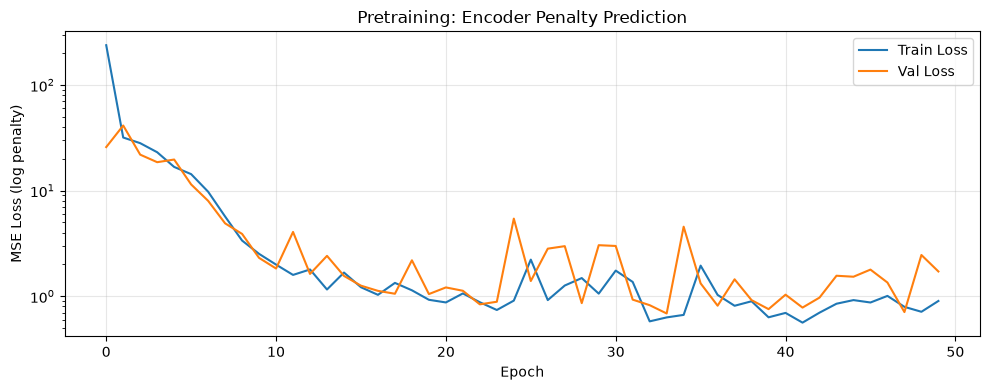


  ✅ Pretraining complete

REWARD FUNCTION TEST
  old_pen=1.0e+15 → new_pen=1.0e+14 | reward=+20.5579
  old_pen=1.0e+14 → new_pen=1.0e+12 | reward=+28.3506
  old_pen=1.0e+06 → new_pen=1.0e+03 | reward=+15.6326
  old_pen=1.0e+03 → new_pen=5.0e-01 | reward=+24.9410
  old_pen=5.0e-01 → new_pen=1.0e-04 | reward=+9.9400
  old_pen=1.0e+03 → new_pen=1.0e+04 | reward=+9.9310

  Adaptive delta_max:
    penalty=1.0e+15 → delta_max=30.0mm
    penalty=1.0e+10 → delta_max=20.0mm
    penalty=1.0e+05 → delta_max=10.0mm
    penalty=1.0e+02 → delta_max=7.0mm
    penalty=5.0e-01 → delta_max=5.0mm
    penalty=1.0e-04 → delta_max=5.0mm

  ✅ Reward function + adaptive delta ready


In [10]:
# ==============================================================================
# CELL 9.5: PRETRAINING + FIXED REWARD + ADAPTIVE DELTA
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader as PyGDataLoader
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output


# ── 9.5.1: FIXED REWARD FUNCTION (log-scale) ────────────────────────────────

def compute_reward(old_penalty: float, new_penalty: float, old_cg: float, 
                   new_cg: float, dx: float, dy: float, cg_bonus_given: bool,
                   cfg: Config) -> tuple:
    """
    Compute reward using log-scale penalty delta + tiered bonuses.
    
    Returns: (reward, cg_bonus_given_flag)
    """
    penalty_delta = old_penalty - new_penalty
    
    # Log-scale reward: handles 1e15 down to 0 smoothly
    # Scale factor: 1e6 (typical "medium" penalty magnitude)
    scale = 1e6
    if abs(penalty_delta) < 1e-6:
        reward_penalty = 0.0
    else:
        reward_penalty = np.sign(penalty_delta) * np.log1p(abs(penalty_delta) / scale)
    
    # Tiered bonuses for crossing thresholds
    threshold_bonus = 0.0
    if old_penalty >= 1e12 and new_penalty < 1e12:
        threshold_bonus += 5.0  # Escaped catastrophic overlap
    if old_penalty >= 1e6 and new_penalty < 1e6:
        threshold_bonus += 5.0  # Major improvement
    if old_penalty >= 1e3 and new_penalty < 1e3:
        threshold_bonus += 5.0  # Getting close
    if old_penalty >= 1.0 and new_penalty < 1.0:
        threshold_bonus += 10.0  # Near valid
    
    # CG bonus (one-time)
    cg_bonus = 0.0
    if new_cg <= cfg.CG_TOLERANCE and not cg_bonus_given:
        cg_bonus = cfg.CG_BONUS
        cg_bonus_given = True
    
    # Step penalty
    step_penalty = -cfg.STEP_PENALTY
    
    # Movement penalty (discourage huge moves)
    move_penalty = -cfg.MOVE_PENALTY_COEF * (dx**2 + dy**2)
    
    total_reward = reward_penalty + threshold_bonus + cg_bonus + step_penalty + move_penalty
    
    return total_reward, cg_bonus_given


# ── 9.5.2: ADAPTIVE DELTA MAX ───────────────────────────────────────────────

def get_delta_max(current_penalty: float, cfg: Config) -> float:
    """
    Adaptive max shift: large when penalty is high, small when refining.
    """
    if current_penalty > 1e12:
        return cfg.DELTA_MAX_START  # 30mm
    elif current_penalty > 1e6:
        return 20.0
    elif current_penalty > 1e3:
        return 10.0
    elif current_penalty > 1.0:
        return 7.0
    else:
        return cfg.DELTA_MAX_END  # 5mm


# ── 9.5.3: UPDATE ENVIRONMENT TO USE NEW REWARD ─────────────────────────────

class PCBEnvV2(PCBEnv):
    """
    Updated environment with log-scale reward and adaptive delta.
    """
    
    def step(self, component_idx: int, dx: float, dy: float) -> tuple:
        self.step_count += 1
        
        old_penalty = self.current_penalty
        old_cg_offset = self.current_cg_offset
        
        # Apply action
        self.current_positions[component_idx * 2] += dx
        self.current_positions[component_idx * 2 + 1] += dy
        self.current_positions = np.clip(
            self.current_positions,
            self.geo['lower_bounds'],
            self.geo['upper_bounds']
        )
        
        # Compute new state
        self.current_penalty = compute_penalty(self.current_positions, self.geo)
        self.current_cg_offset = self._compute_cg_offset(self.current_positions)
        
        # Compute reward using new function
        reward, self.cg_bonus_given = compute_reward(
            old_penalty, self.current_penalty,
            old_cg_offset, self.current_cg_offset,
            dx, dy, self.cg_bonus_given,
            self.cfg
        )
        
        self.episode_reward += reward
        
        # Done conditions
        done = False
        info = {
            'penalty': self.current_penalty,
            'cg_offset': self.current_cg_offset,
            'step': self.step_count,
            'episode_reward': self.episode_reward,
            'delta_max': get_delta_max(self.current_penalty, self.cfg),
        }
        
        if self.current_penalty < cfg.PENALTY_THRESHOLD:
            done = True
            info['success'] = True
            info['reason'] = 'penalty_threshold'
        elif self.step_count >= cfg.MAX_STEPS_PER_EPISODE:
            done = True
            info['success'] = False
            info['reason'] = 'max_steps'
        
        next_graph = build_graph(self.current_positions, self.geo, self.static_features,
                                penalty=self.current_penalty, cg_offset=self.current_cg_offset)
        
        return next_graph, reward, done, info


# ── 9.5.4: DATASET TO PYG CONVERSION FOR PRETRAINING ────────────────────────

def npz_to_pyg_data(npz_path: str, target_n: int, geo: dict, static_features: torch.Tensor) -> Data:
    """
    Load a dataset .npz file and convert to PyG Data for pretraining.
    Pads/truncates positions to match target component count.
    """
    data = np.load(npz_path, allow_pickle=True)
    
    pos = data['best_sol'].copy()
    penalty = float(data['penalty'].item())
    
    # Pad or truncate
    target_len = target_n * 2
    if len(pos) < target_len:
        padded = np.zeros(target_len)
        padded[:len(pos)] = pos
        for i in range(len(pos)//2, target_n):
            idx = i * 2
            padded[idx] = np.random.uniform(geo['lower_bounds'][idx], geo['upper_bounds'][idx])
            padded[idx+1] = np.random.uniform(geo['lower_bounds'][idx+1], geo['upper_bounds'][idx+1])
        pos = padded
    else:
        pos = pos[:target_len]
    
    # Build graph
    graph = build_graph(pos, geo, static_features, penalty=penalty)
    
    # Add target label (penalty)
    graph.penalty_target = torch.tensor(penalty, dtype=torch.float32)
    
    return graph


# ── 9.5.5: PRETRAIN ENCODER TO PREDICT PENALTY ───────────────────────────────

print("=" * 60)
print("PRETRAINING: ENCODER + VALUE HEAD")
print("=" * 60)

# Prepare dataset
print("  Loading dataset files for pretraining...")
pretrain_graphs = []
for fpath in train_files[:500]:  # Use 500 files for speed
    try:
        g = npz_to_pyg_data(fpath, GEO['n'], GEO, static_feat.to(DEVICE))
        pretrain_graphs.append(g)
    except Exception as e:
        pass

print(f"  Loaded {len(pretrain_graphs)} valid graphs")

# Split into train/val for pretraining
split_pt = int(len(pretrain_graphs) * 0.9)
pretrain_train = pretrain_graphs[:split_pt]
pretrain_val = pretrain_graphs[split_pt:]

print(f"  Pretrain split: {len(pretrain_train)} train / {len(pretrain_val)} val")

# Create a simple penalty predictor head
class PenaltyPredictor(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    
    def forward(self, global_emb):
        # Predict log(penalty + 1) for stability
        return self.head(global_emb).squeeze(-1)


# Pretraining setup
pretrain_model = GNNPolicy(
    node_dim=18, edge_dim=5, hidden_dim=cfg.HIDDEN_DIM,
    num_layers=cfg.GNN_LAYERS, global_dim=cfg.GLOBAL_FEATURE_DIM
).to(DEVICE)

penalty_head = PenaltyPredictor(cfg.HIDDEN_DIM).to(DEVICE)

pretrain_optimizer = torch.optim.Adam(
    list(pretrain_model.encoder.parameters()) + 
    list(pretrain_model.value_head.parameters()) +
    list(penalty_head.parameters()),
    lr=cfg.PRETRAIN_LR
)

pretrain_criterion = nn.MSELoss()

# Pretraining loop
print(f"\n  Pretraining for {cfg.PRETRAIN_EPOCHS} epochs...")
pretrain_losses = []
pretrain_val_losses = []

for epoch in range(cfg.PRETRAIN_EPOCHS):
    pretrain_model.train()
    epoch_losses = []
    
    # Shuffle and batch
    np.random.shuffle(pretrain_train)
    
    for i in range(0, len(pretrain_train), cfg.PRETRAIN_BATCH_SIZE):
        batch = pretrain_train[i:i+cfg.PRETRAIN_BATCH_SIZE]
        
        penalties = []
        for g in batch:
            g_device = g.to(DEVICE)
            batch_vec = torch.zeros(g_device.num_nodes, dtype=torch.long, device=DEVICE)
            
            _, global_emb = pretrain_model.encoder(
                g_device.x, g_device.edge_index, g_device.edge_attr, batch_vec
            )
            
            pred = penalty_head(global_emb)
            target = torch.log1p(torch.tensor(g_device.penalty.item(), device=DEVICE))
            penalties.append((pred, target))
        
        loss = sum(F.mse_loss(p, t) for p, t in penalties) / len(penalties)
        
        pretrain_optimizer.zero_grad()
        loss.backward()
        pretrain_optimizer.step()
        
        epoch_losses.append(loss.item())
    
    # Validation
    pretrain_model.eval()
    val_losses = []
    with torch.no_grad():
        for g in pretrain_val:
            g_device = g.to(DEVICE)
            batch_vec = torch.zeros(g_device.num_nodes, dtype=torch.long, device=DEVICE)
            _, global_emb = pretrain_model.encoder(
                g_device.x, g_device.edge_index, g_device.edge_attr, batch_vec
            )
            pred = penalty_head(global_emb)
            target = torch.log1p(torch.tensor(g_device.penalty.item(), device=DEVICE))
            val_losses.append(F.mse_loss(pred, target).item())
    
    avg_train = np.mean(epoch_losses)
    avg_val = np.mean(val_losses)
    pretrain_losses.append(avg_train)
    pretrain_val_losses.append(avg_val)
    
    if (epoch + 1) % 10 == 0:
        print(f"    Epoch {epoch+1:3d}: train_loss={avg_train:.4f}, val_loss={avg_val:.4f}")

# Plot pretraining curves
plt.figure(figsize=(10, 4))
plt.plot(pretrain_losses, label='Train Loss')
plt.plot(pretrain_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log penalty)')
plt.title('Pretraining: Encoder Penalty Prediction')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n  ✅ Pretraining complete")


# ── 9.5.6: TEST NEW REWARD FUNCTION ──────────────────────────────────────────

print(f"\n{'=' * 60}")
print("REWARD FUNCTION TEST")
print(f"{'=' * 60}")

# Test cases
test_cases = [
    (1e15, 1e14, 2.0, 1.5),   # Big improvement
    (1e14, 1e12, 1.5, 1.0),   # Crossing 1e12 threshold
    (1e6, 1e3, 1.0, 0.8),     # Crossing 1e6 and 1e3
    (1e3, 0.5, 0.8, 0.5),     # Near valid
    (0.5, 0.0001, 0.5, 0.3),  # Already valid
    (1e3, 1e4, 0.5, 0.6),     # Got worse
]

for old_p, new_p, old_cg, new_cg in test_cases:
    r, _ = compute_reward(old_p, new_p, old_cg, new_cg, 5.0, 5.0, False, cfg)
    print(f"  old_pen={old_p:.1e} → new_pen={new_p:.1e} | reward={r:+.4f}")

# Test adaptive delta
print(f"\n  Adaptive delta_max:")
for pen in [1e15, 1e10, 1e5, 1e2, 0.5, 0.0001]:
    d = get_delta_max(pen, cfg)
    print(f"    penalty={pen:.1e} → delta_max={d:.1f}mm")

print(f"\n  ✅ Reward function + adaptive delta ready")

In [13]:
# ==============================================================================
# CELL 10 (OPTIMIZED): FAST TRAINING WITH CACHED GRAPHS + FIXED REWARD
# ==============================================================================

import time
import torch
import numpy as np


# ── 10.1: OPTIMIZED ENVIRONMENT — Cache static graph structure ───────────────

class FastPCBEnv(PCBEnv):
    """
    Optimized environment that caches static graph structure.
    Only updates dynamic features (positions, penalty, violation mask) per step.
    """
    
    def __init__(self, geo, static_features, dataset_files=None, use_dataset_prob=0.7, config=None):
        super().__init__(geo, static_features, dataset_files, use_dataset_prob)
        self.config = config if config is not None else cfg
        self.device = static_features.device
        
        # Precompute static edge structure (never changes)
        self._precompute_static_edges()
        
        # Precompute static node features (first 14 dims never change)
        self.static_node_features = static_features.cpu().numpy()
    
    def _precompute_static_edges(self):
        """Build edge index and static edge features once."""
        n = self.n
        
        # Edge index: fully connected, directed
        edge_index = []
        for i in range(n):
            for j in range(n):
                if i != j:
                    edge_index.append([i, j])
        
        self.edge_index = torch.tensor(edge_index, dtype=torch.long, device=self.device).t().contiguous()
        
        # Static edge features: req_dist, same_side (don't change)
        edge_attr_static = []
        for i in range(n):
            for j in range(n):
                if i != j:
                    req_dist = self.geo['req_d_matrix'][i, j]
                    same_side = 1.0 if self.geo['is_back_side'][i] == self.geo['is_back_side'][j] else 0.0
                    edge_attr_static.append([0.0, 0.0, 0.0, req_dist, same_side])  # dist, dx, dy placeholder
        
        self.edge_attr_static = torch.tensor(edge_attr_static, dtype=torch.float32, device=self.device)
    
    def _build_fast_graph(self, positions, penalty, cg_offset):
        """Build graph reusing cached static features. Much faster."""
        n = self.n
        
        # Extract positions
        cx = positions[::2]
        cy = positions[1::2]
        abs_x = np.where(self.geo['is_back_side'] == 1, -cx, cx)
        
        # Dynamic node features
        dynamic = np.stack([cx, cy, abs_x, np.zeros(n)], axis=1)
        
        # Full node features: static + dynamic
        x = np.concatenate([self.static_node_features, dynamic], axis=1)
        x = torch.tensor(x, dtype=torch.float32, device=self.device)
        
        # Update edge distances (only dynamic part)
        edge_attr = self.edge_attr_static.clone()
        edge_idx = 0
        for i in range(n):
            for j in range(n):
                if i != j:
                    dx = abs_x[j] - abs_x[i]
                    dy = cy[j] - cy[i]
                    dist = np.sqrt(dx**2 + dy**2)
                    edge_attr[edge_idx, 0] = dist
                    edge_attr[edge_idx, 1] = dx
                    edge_attr[edge_idx, 2] = dy
                    edge_idx += 1
        
        # Global features
        global_feat = torch.tensor([
            self.geo['panel_width'],
            self.geo['panel_height'],
            self.geo['border_spacing'],
            penalty,
            cg_offset,
        ], dtype=torch.float32, device=self.device).unsqueeze(0)
        
        # Violation mask (fast computation)
        violation_mask = self._fast_violation_mask(positions, abs_x, cy)
        
        data = Data(
            x=x,
            edge_index=self.edge_index,
            edge_attr=edge_attr,
            num_nodes=n,
            global_features=global_feat,
            violation_mask=torch.tensor(violation_mask, dtype=torch.bool, device=self.device),
            positions=torch.tensor(positions, dtype=torch.float32, device=self.device),
            penalty=torch.tensor(penalty, dtype=torch.float32, device=self.device),
        )
        
        return data
    
    def _fast_violation_mask(self, positions, abs_x, cy):
        """Optimized violation check."""
        n = self.n
        mask = np.zeros(n, dtype=bool)
        
        active_x_min = -self.geo['panel_width'] / 2.0 + self.geo['border_spacing']
        active_x_max = self.geo['panel_width'] / 2.0 - self.geo['border_spacing']
        active_y_min = -self.geo['panel_height'] / 2.0 + self.geo['border_spacing']
        active_y_max = self.geo['panel_height'] / 2.0 - self.geo['border_spacing']
        
        for i in range(n):
            violated = False
            
            # Border check
            c_top = self.geo['clearance_dirs'][i, 0]
            c_right = self.geo['clearance_dirs'][i, 3] if self.geo['is_back_side'][i] else self.geo['clearance_dirs'][i, 1]
            c_bot = self.geo['clearance_dirs'][i, 2]
            c_left = self.geo['clearance_dirs'][i, 1] if self.geo['is_back_side'][i] else self.geo['clearance_dirs'][i, 3]
            
            hl = self.geo['lengths'][i] / 2.0
            hw = self.geo['widths'][i] / 2.0
            
            i_x_min = abs_x[i] - hl - c_left
            i_x_max = abs_x[i] + hl + c_right
            i_y_min = cy[i] - hw - c_bot
            i_y_max = cy[i] + hw + c_top
            
            if (i_x_min < active_x_min or i_x_max > active_x_max or
                i_y_min < active_y_min or i_y_max > active_y_max):
                violated = True
            
            # Overlap check (same side only, early exit)
            if not violated:
                for j in range(n):
                    if i == j or self.geo['is_back_side'][i] != self.geo['is_back_side'][j]:
                        continue
                    
                    cj_top = self.geo['clearance_dirs'][j, 0]
                    cj_right = self.geo['clearance_dirs'][j, 3] if self.geo['is_back_side'][j] else self.geo['clearance_dirs'][j, 1]
                    cj_bot = self.geo['clearance_dirs'][j, 2]
                    cj_left = self.geo['clearance_dirs'][j, 1] if self.geo['is_back_side'][j] else self.geo['clearance_dirs'][j, 3]
                    
                    jhl = self.geo['lengths'][j] / 2.0
                    jhw = self.geo['widths'][j] / 2.0
                    
                    j_x_min = abs_x[j] - jhl - cj_left
                    j_x_max = abs_x[j] + jhl + cj_right
                    j_y_min = cy[j] - jhw - cj_bot
                    j_y_max = cy[j] + jhw + cj_top
                    
                    if (min(i_x_max, j_x_max) > max(i_x_min, j_x_min) and
                        min(i_y_max, j_y_max) > max(i_y_min, j_y_min)):
                        violated = True
                        break
            
            mask[i] = violated
        
        return mask
    
    def reset(self, positions=None):
        self.step_count = 0
        self.episode_reward = 0.0
        self.cg_bonus_given = False
        
        if positions is not None:
            self.current_positions = positions.copy()
        else:
            self.current_positions = self._sample_initial_layout()
        
        self.current_penalty = compute_penalty(self.current_positions, self.geo)
        self.current_cg_offset = self._compute_cg_offset(self.current_positions)
        
        return self._build_fast_graph(self.current_positions, self.current_penalty, self.current_cg_offset)
    
    def step(self, component_idx, dx, dy):
        self.step_count += 1
        old_penalty = self.current_penalty
        old_cg_offset = self.current_cg_offset
        
        self.current_positions[component_idx * 2] += dx
        self.current_positions[component_idx * 2 + 1] += dy
        self.current_positions = np.clip(
            self.current_positions,
            self.geo['lower_bounds'],
            self.geo['upper_bounds']
        )
        
        self.current_penalty = compute_penalty(self.current_positions, self.geo)
        self.current_cg_offset = self._compute_cg_offset(self.current_positions)
        
        reward, self.cg_bonus_given = compute_reward_v2(
            old_penalty, self.current_penalty,
            old_cg_offset, self.current_cg_offset,
            dx, dy, self.cg_bonus_given,
            self.config
        )
        
        self.episode_reward += reward
        
        done = False
        info = {
            'penalty': self.current_penalty,
            'cg_offset': self.current_cg_offset,
            'step': self.step_count,
            'episode_reward': self.episode_reward,
        }
        
        if self.current_penalty < self.config.PENALTY_THRESHOLD:
            done = True
            info['success'] = True
            info['reason'] = 'penalty_threshold'
        elif self.step_count >= self.config.MAX_STEPS_PER_EPISODE:
            done = True
            info['success'] = False
            info['reason'] = 'max_steps'
        
        next_graph = self._build_fast_graph(self.current_positions, self.current_penalty, self.current_cg_offset)
        
        return next_graph, reward, done, info


# ── 10.2: SPEED TEST ─────────────────────────────────────────────────────────

print("=" * 60)
print("SPEED TEST: Optimized vs Original")
print("=" * 60)

# Original env
orig_env = PCBEnvFinal(GEO, static_feat.to(DEVICE), dataset_files=train_files[:10], config=cfg)

# Optimized env
fast_env = FastPCBEnv(GEO, static_feat.to(DEVICE), dataset_files=train_files[:10], config=cfg)

# Test reset
print("\n--- Reset ---")
t0 = time.time()
_ = orig_env.reset()
t_orig = time.time() - t0

t0 = time.time()
_ = fast_env.reset()
t_fast = time.time() - t0

print(f"  Original: {t_orig*1000:.1f} ms")
print(f"  Optimized: {t_fast*1000:.1f} ms")
print(f"  Speedup: {t_orig/t_fast:.1f}x")

# Test step
print("\n--- Step ---")
state = fast_env.reset()
with torch.no_grad():
    comp, dx, dy, _, _ = small_model.select_action(state, delta_max=30.0)

t0 = time.time()
_ = orig_env.step(comp, dx, dy)
t_orig = time.time() - t0

t0 = time.time()
_ = fast_env.step(comp, dx, dy)
t_fast = time.time() - t0

print(f"  Original: {t_orig*1000:.1f} ms")
print(f"  Optimized: {t_fast*1000:.1f} ms")
print(f"  Speedup: {t_orig/t_fast:.1f}x")


# ── 10.3: FAST TRAINING LOOP ─────────────────────────────────────────────────

print(f"\n{'=' * 60}")
print("FAST TRAINING — Optimized Environment")
print(f"{'=' * 60}")

# Use smaller config
fast_cfg = Config()
fast_cfg.ROLLOUT_STEPS = 512
fast_cfg.NUM_ENVS = 8
fast_cfg.PPO_EPOCHS = 4
fast_cfg.MINIBATCH_SIZE = 64
fast_cfg.MAX_STEPS_PER_EPISODE = 30
fast_cfg.HIDDEN_DIM = 128
fast_cfg.GNN_LAYERS = 2

# Small model
fast_model = GNNPolicy(
    node_dim=18, edge_dim=5, hidden_dim=fast_cfg.HIDDEN_DIM,
    num_layers=fast_cfg.GNN_LAYERS, global_dim=fast_cfg.GLOBAL_FEATURE_DIM
).to(DEVICE)

fast_trainer = PPOTrainerV2(fast_model, fast_cfg, pretrain_model=None)

fast_envs = [FastPCBEnv(GEO, static_feat.to(DEVICE), dataset_files=train_files[:50], config=fast_cfg) 
             for _ in range(fast_cfg.NUM_ENVS)]

print(f"  Envs: {fast_cfg.NUM_ENVS}")
print(f"  Rollout steps: {fast_cfg.ROLLOUT_STEPS}")
print(f"  Hidden dim: {fast_cfg.HIDDEN_DIM}")
print(f"  Model params: {sum(p.numel() for p in fast_model.parameters()):,}")

feasible_layouts = []
update_count = 0
max_updates = 100

start_time = time.time()

while len(feasible_layouts) < fast_cfg.TARGET_LAYOUT_COUNT and update_count < max_updates:
    # Rollout
    t0 = time.time()
    buffer = fast_trainer.collect_rollouts(fast_envs)
    t_rollout = time.time() - t0
    
    # Update
    t0 = time.time()
    metrics = fast_trainer.update(buffer)
    t_update = time.time() - t0
    
    update_count += 1
    
    # Print every update
    elapsed = time.time() - start_time
    print(f"[U{update_count:3d}] {elapsed/60:.1f}min | "
          f"rollout={t_rollout:.1f}s update={t_update:.1f}s | "
          f"reward={metrics['reward_mean']:+.2f} | "
          f"policy_loss={metrics['policy_loss']:.3f} | "
          f"value_loss={metrics['value_loss']:.3f}")
    
    # Test every 10 updates
    if update_count % 10 == 0:
        test_env = FastPCBEnv(GEO, static_feat.to(DEVICE), dataset_files=train_files[:50], config=fast_cfg)
        penalties = []
        for _ in range(10):
            state = test_env.reset()
            for step in range(fast_cfg.MAX_STEPS_PER_EPISODE):
                with torch.no_grad():
                    comp, dx, dy, _, _ = fast_model.select_action(state, delta_max=30.0, deterministic=True)
                state, reward, done, info = test_env.step(comp, dx, dy)
                if done:
                    penalties.append(info['penalty'])
                    break
            else:
                penalties.append(info['penalty'])
        
        successes = sum(1 for p in penalties if p < fast_cfg.PENALTY_THRESHOLD)
        print(f"  >>> TEST: {successes}/10 successes | median_pen={np.median(penalties):.2e}")

print(f"\n{'=' * 60}")
print(f"Done: {len(feasible_layouts)} layouts found in {update_count} updates")

SPEED TEST: Optimized vs Original

--- Reset ---
  Original: 157.8 ms
  Optimized: 47.6 ms
  Speedup: 3.3x

--- Step ---
  Original: 118.8 ms
  Optimized: 28.3 ms
  Speedup: 4.2x

FAST TRAINING — Optimized Environment
  Envs: 8
  Rollout steps: 512
  Hidden dim: 128
  Model params: 301,702
[U  1] 0.8min | rollout=30.8s update=18.7s | reward=-48.85 | policy_loss=4.881 | value_loss=9.340
[U  2] 1.6min | rollout=30.6s update=18.2s | reward=-47.94 | policy_loss=6.774 | value_loss=8.067
[U  3] 2.5min | rollout=31.1s update=18.2s | reward=-47.57 | policy_loss=2.286 | value_loss=7.288
[U  4] 3.3min | rollout=30.6s update=18.2s | reward=-49.41 | policy_loss=37.078 | value_loss=8.362
[U  5] 4.1min | rollout=30.4s update=18.3s | reward=-48.49 | policy_loss=6.807 | value_loss=9.568
[U  6] 4.9min | rollout=31.0s update=18.4s | reward=-53.11 | policy_loss=6.005 | value_loss=9.232
[U  7] 5.7min | rollout=30.8s update=18.3s | reward=-53.39 | policy_loss=5.915 | value_loss=6.471
[U  8] 6.5min | rollou

KeyboardInterrupt: 